In [1]:
%pip install numpy
%pip install scipy
%pip install matplotlib


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [29]:
import numpy as np
import numpy.linalg as linalg
from scipy.integrate import ode
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

In [35]:
def solve_wave(k: float, A: float, space_freq: float, spring_count: int, max_t: float, dt: float = 0.01
                  ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    def derivatives(t: float, state: np.ndarray) -> np.ndarray:
        x = state[:len(state) // 2]
        v = state[len(state) // 2:]

        F_link = k * (x[1:] - x[:-1])
        a = np.concat([[0], F_link[1:] - F_link[:-1], [0]])

        derivatives = np.concat([v, a])
        return derivatives

    integrator = ode(derivatives)

    initial_x = A * np.sin(space_freq * np.arange(spring_count)) 
    initial_x[0] = 0
    initial_x[-1] = 0

    initial_v = A * 10 * np.cos(space_freq * np.arange(spring_count))
    initial_v[0] = 0
    initial_v[-1] = 0

    initial_state = np.concat([initial_x, initial_v])
    integrator.set_initial_value(initial_state, 0)

    t_values = []
    x_values = []
    v_values = []

    while integrator.successful() and integrator.t < max_t:
        state = integrator.integrate(integrator.t + dt)
        t_values.append(integrator.t)
        x_values.append(state[:len(state) // 2])
        v_values.append(state[len(state) // 2:])

    return (np.array(t_values), np.array(x_values), np.array(v_values))

In [72]:
K = 1000
DELTA_T = 0.01
DELTA_POS = 1
t, x, v = solve_wave(K, 1, np.pi / 4, 100, 1, DELTA_T)

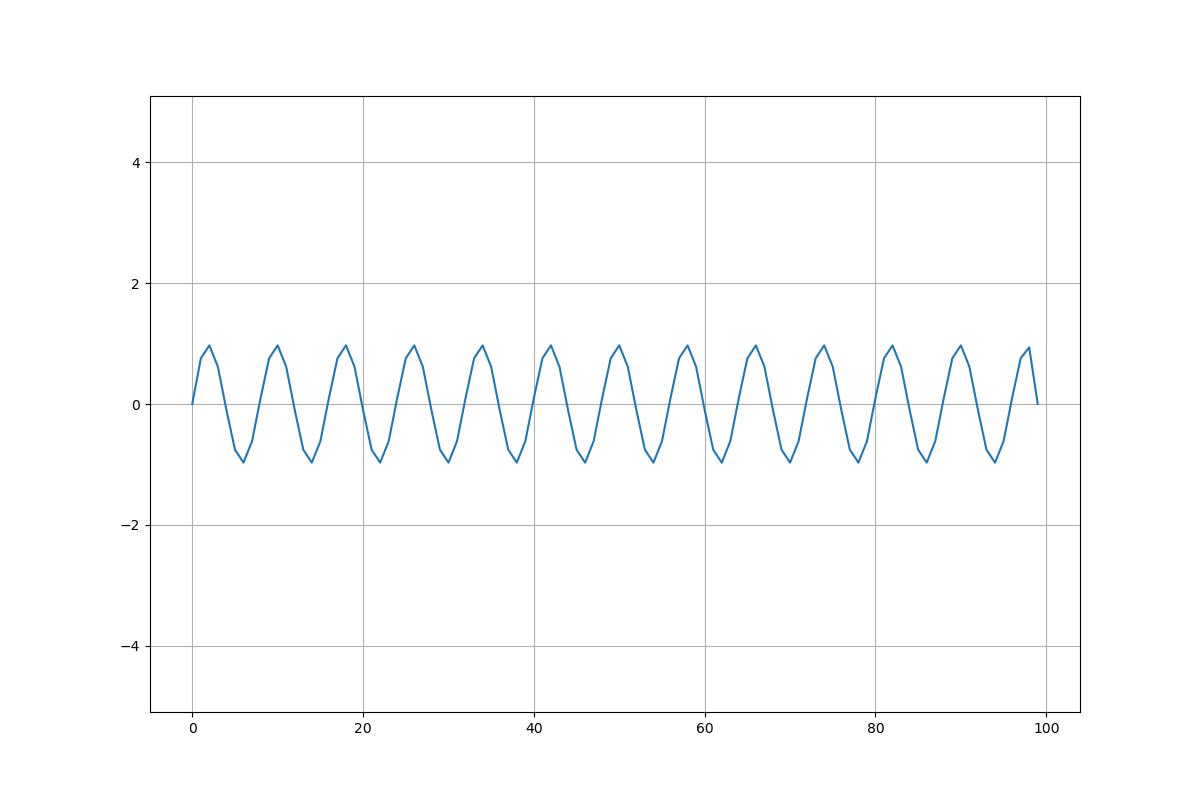

In [73]:
%matplotlib widget

def wave_profile(t, x) -> tuple[np.ndarray, np.ndarray]:
    return np.arange(len(x[t])), x[t]

fig, ax = plt.subplots(figsize=(12, 8))
wave, = plt.plot(*wave_profile(0, x))
plt.ylim(-5.1, 5.1)
plt.grid(True)
plt.show()

def update(frame):
    wave.set_data(*wave_profile(frame, x))
    return wave,

try:
    anim.event_source.stop()
except NameError:
    pass
anim = FuncAnimation(fig, update, len(x), interval=50)

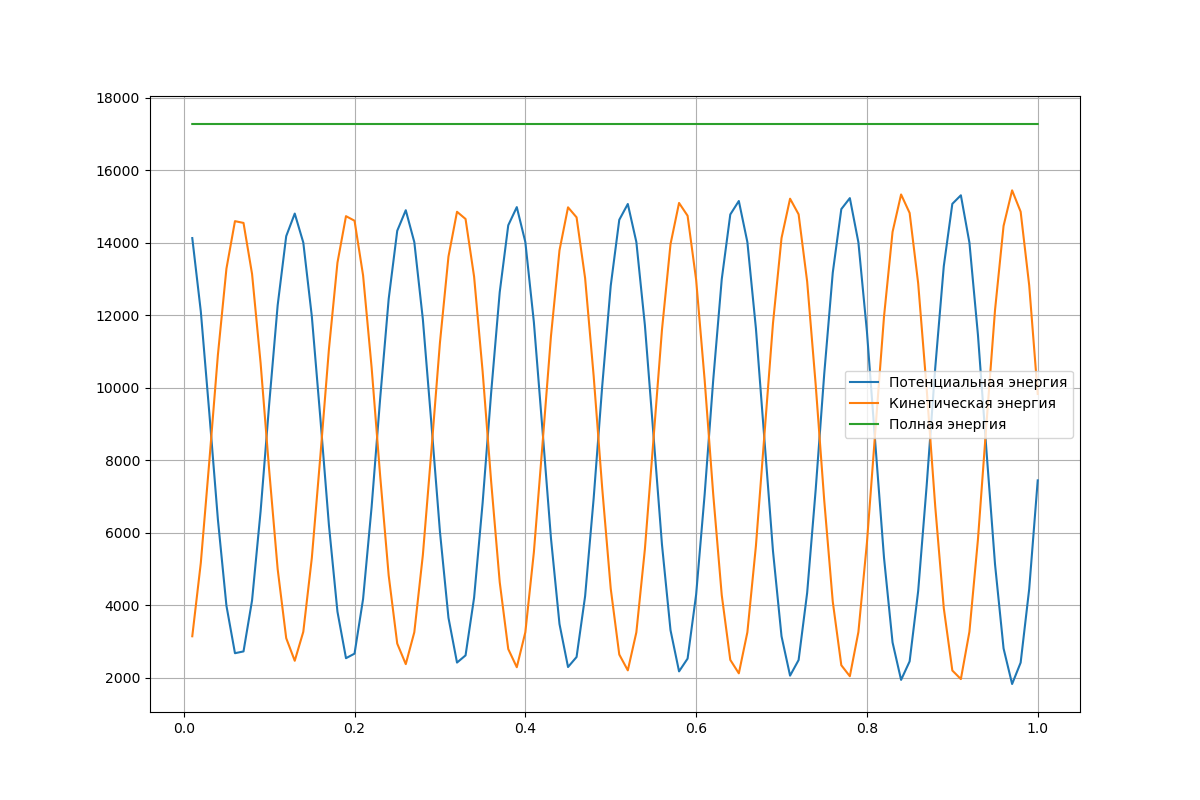

In [74]:
potential_energy = np.sum(K * (x[:, 1:] - x[:, :-1]) ** 2 / 2, axis=1)
kinetic_energy = np.sum(v**2 / 2, axis=1)

plt.figure(figsize=(12, 8))
plt.plot(t, potential_energy, label="Потенциальная энергия")
plt.plot(t, kinetic_energy, label="Кинетическая энергия")
plt.plot(t, potential_energy + kinetic_energy, label="Полная энергия")

plt.legend()
plt.grid(True)
plt.show()

In [76]:
d2x_dt2 = (x[2:, :] + x[:-2, :] - 2 * x[1:-1, :])[:, 1:-1] / DELTA_T ** 2
d2x_dpos2 = (x[:, 2:] + x[:, :-2] - 2 * x[:, 1:-1])[1:-1, :] / DELTA_POS ** 2

c = np.sqrt(np.abs((d2x_dt2 / d2x_dpos2)))
print(np.average(c), np.sqrt(K))

31.72976970183243 31.622776601683793
